# Do the exposures travel to the next month?

Freeze a 60-month exposure estimate, supply the next month's realized factors, and measure reconstruction error. Compare coefficient movement with tracking accuracy, then examine the bias introduced by shrinkage and discarded directions.

In [1]:
from pathlib import Path
import sys
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'research/models.py').exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image
plt.rcParams.update({'font.size': 10, 'axes.spines.top': False, 'axes.spines.right': False})
RESULTS = ROOT / 'research/results'
FIGURES = ROOT / 'research/figures'


## Question and timing
The coefficients are fitted through t−1. Factor returns for t are observed afterward and enter the reconstruction. This is a test of exposure portability conditional on realized factors, not an ex ante return forecast. The source files are also revised vintages.

In [2]:
from research.data import load_panel
from research.run_study import rolling_reconstruction, comparison, summarize
x, y, audit = load_panel()
paths = rolling_reconstruction(x, y)
assert (paths.train_end < paths.month).all()
display(summarize(paths).round(4))

,model,months,etfs,rmse_pct_monthly,mse_pp2,rms_beta_monthly_change,mean_effective_df_including_intercept
0,Market,175,9,3.4769,12.0887,0.0094,2.000
1,FF5,175,9,3.0371,9.2243,0.0412,6.000
2,OLS,175,9,3.0368,9.2219,0.0436,7.000
3,Ridge 0.1,175,9,3.0025,9.0153,0.0348,6.153
4,PCR 4,175,9,3.3216,11.0331,0.0881,5.000


## Paired panel comparison
Average squared percentage-point errors equally across the 9 primary State Street sector funds within each month. Resample those paired months in common 12-month blocks, retaining sector dependence.

,Ridge minus OLS comparison
estimate,-0.206653
lower95,-0.425645
upper95,-0.014282
relative_mse_reduction_pct,2.240887
n,175.000000


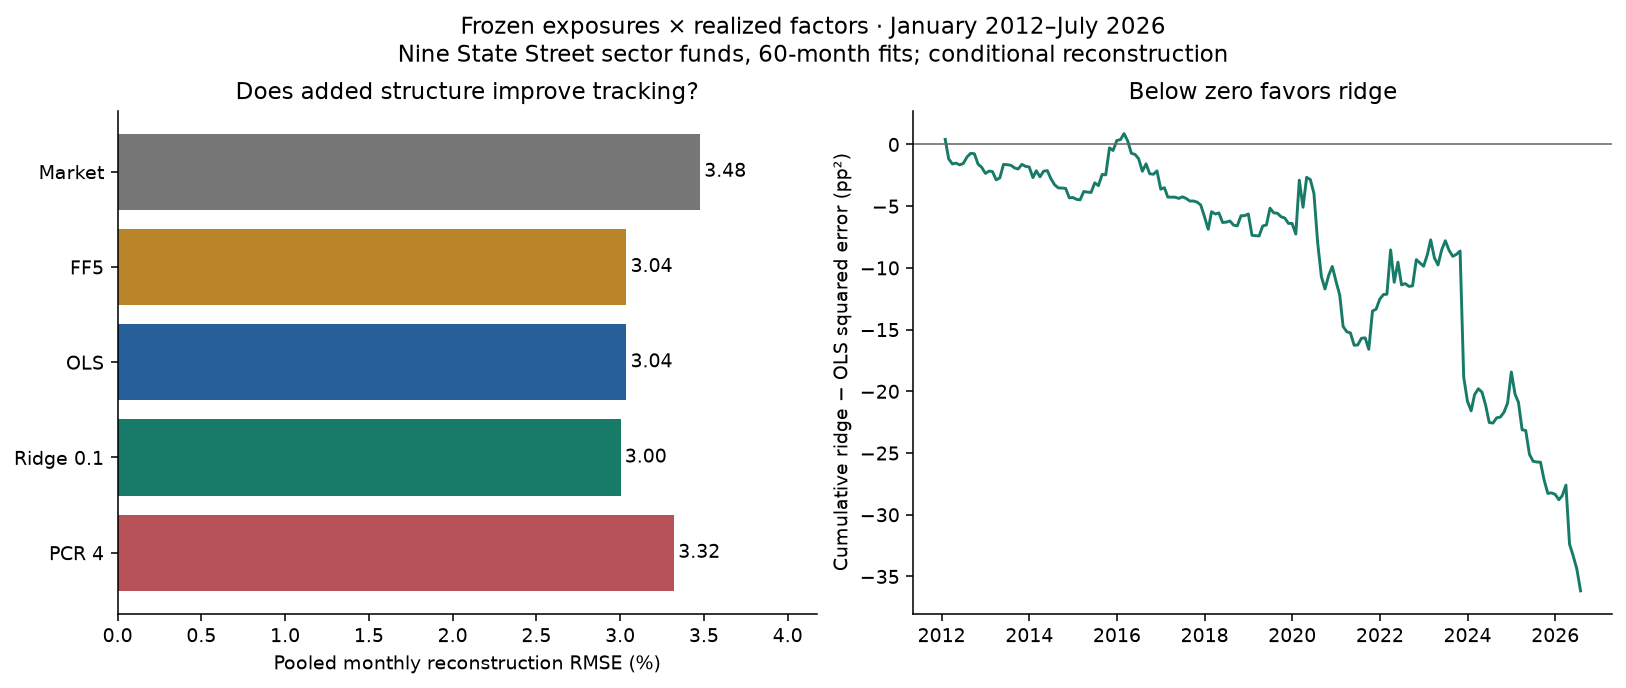

In [3]:
interval = comparison(paths)
display(pd.Series({k: interval[k] for k in ['estimate', 'lower95', 'upper95', 'relative_mse_reduction_pct', 'n']}).to_frame('Ridge minus OLS comparison'))
display(Image(filename=str(FIGURES / 'reconstruction.png')))

## Stable is not necessarily more accurate
The next figure uses all six raw slopes for the change statistic. PCR's lower dimensional subspace can move from one rolling fit to the next, so lower rank need not give smoother economic betas.

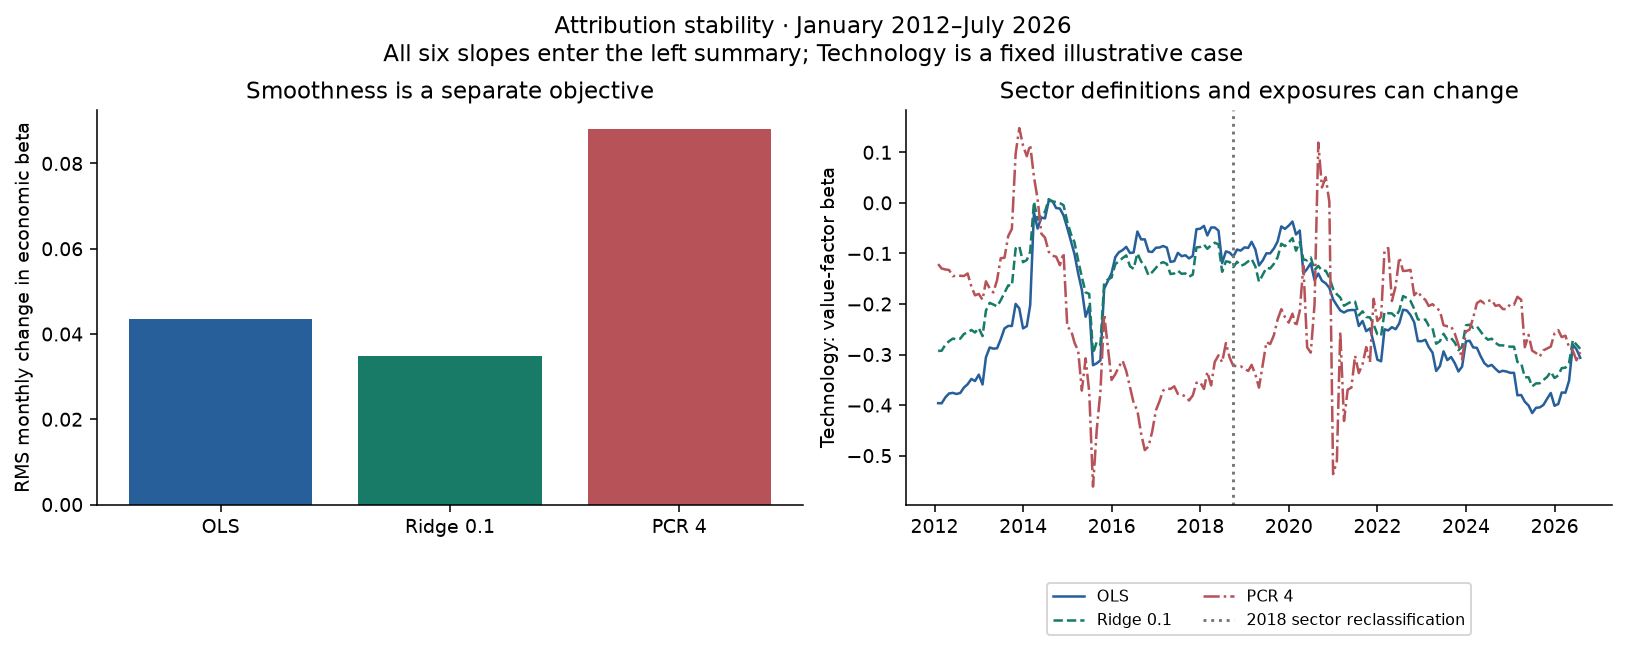

In [4]:
display(Image(filename=str(FIGURES / 'stability.png')))

## Retain the unfavorable sensitivities
Larger shrinkage can remove useful exposures. Compare every fixed penalty/rank, then compare windows on the same January 2017–July 2026 dates. These diagnostics do not replace the primary 60-month specification.

In [5]:
display(pd.read_csv(RESULTS / 'estimator_sensitivity.csv').round(4))
windows = pd.read_csv(RESULTS / 'window_sensitivity.csv')
display(windows[windows.scope.eq('common dates')][['window', 'estimate', 'lower95', 'upper95', 'relative_mse_reduction_pct']].round(4))

,model,months,etfs,rmse_pct_monthly,mse_pp2,rms_beta_monthly_change,mean_effective_df_including_intercept
0,Market,175,9,3.4769,12.0887,0.0094,2.0000
1,FF5,175,9,3.0371,9.2243,0.0412,6.0000
2,OLS,175,9,3.0368,9.2219,0.0436,7.0000
3,Ridge 0.1,175,9,3.0025,9.0153,0.0348,6.1530
4,PCR 4,175,9,3.3216,11.0331,0.0881,5.0000
5,Ridge 0.01,175,9,3.0262,9.1578,0.0423,6.8963
6,Ridge 1,175,9,3.5654,12.7121,0.0193,3.6272
7,PCR 3,175,9,3.8945,15.1673,0.0555,4.0000
8,PCR 5,175,9,3.0995,9.6067,0.0902,6.0000


,window,estimate,lower95,upper95,relative_mse_reduction_pct
1,60,-0.2830,-0.5973,0.0015,2.5171
3,36,-0.5727,-1.0036,-0.1877,4.8445
5,120,-0.1701,-0.4575,0.0998,1.5451


## Research decision
Ridge's reconstruction MSE is **2.24% lower** relative to OLS on the point estimate. The paired ridge-minus-OLS difference is **-0.207 pp²**, with a 95% block interval **[-0.426, -0.014]**. The paired interval supports lower reconstruction error for ridge in this panel. Coefficient stability and bounded sensitivities describe other aspects of the fit; none replaces this primary endpoint. The eleven-sector extension has a shorter evaluation period and remains supplemental. [Full results](../../docs/03-results.md) retain the complete record.